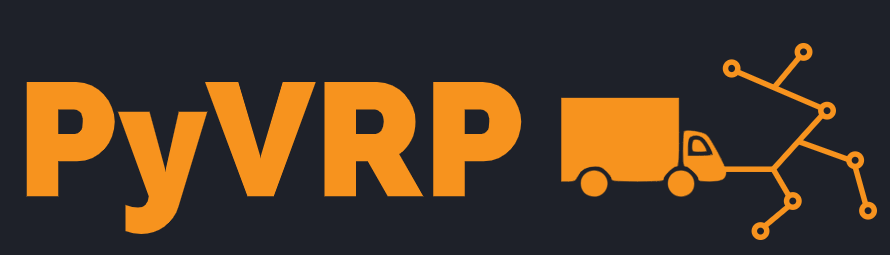

In [1]:
%pip install pyvrp
import random
import matplotlib.pyplot as plt
from pyvrp import Model
from pyvrp.stop import MaxIterations
from pyvrp.plotting import plot_coordinates, plot_result
import itertools

In [2]:
import random
import itertools
from pyvrp import Model
from pyvrp.stop import MaxIterations

def generate_cvrp_instance(num_customers=15, num_vehicles=3, vehicle_capacity=35, seed=42):
    random.seed(seed)

    # Create nodes (0 = depot)
    locations = {0: (random.randint(40, 60), random.randint(40, 60))}  # centered depot
    for i in range(1, num_customers + 1):
        locations[i] = (random.randint(0, 100), random.randint(0, 100))

    # Create random demands (customers only)
    demand = {0: 0}
    total_demand = 0
    for j in range(1, num_customers + 1):
        d = random.randint(5, 7)
        demand[j] = d
        total_demand += d

    # Ensure that total vehicle capacity is sufficient
    total_capacity = num_vehicles * vehicle_capacity
    assert total_capacity >= total_demand, (
        f"Insufficient capacity: total demand = {total_demand}, available capacity = {total_capacity}"
    )

    # Compute Euclidean distances
    nodes = list(locations.keys())
    dist = {
        (i, j): int(round(((locations[i][0] - locations[j][0]) ** 2 +
                           (locations[i][1] - locations[j][1]) ** 2) ** 0.5))
        for i, j in itertools.permutations(nodes, 2)
    }

    # Customers and vehicles
    customers = [i for i in nodes if i != 0]
    vehicles = list(range(1, num_vehicles + 1))

    return locations, demand, dist, customers, vehicles, vehicle_capacity

num_vehicles = 3
# Generate instance
locations, demand, dist, customers, vehicles, Q = generate_cvrp_instance(
    num_customers=15,
    num_vehicles=num_vehicles,
    vehicle_capacity=35,
    seed=42,
)

# Build the model
model = Model()
model.add_vehicle_type(num_vehicles, capacity=Q)

# Add depot
x_dep, y_dep = locations[0]
depot = model.add_depot(x=x_dep, y=y_dep)

# Add customers
customer_nodes = {}
for idx in range(1, len(locations)):
    x, y = locations[idx]
    delivery = demand[idx]
    customer_nodes[idx] = model.add_client(x=x, y=y, delivery=delivery)

# Add edges with Euclidean distances
for i in locations:
    for j in locations:
        xi, yi = locations[i]
        xj, yj = locations[j]
        distance = ((xi - xj) ** 2 + (yi - yj) ** 2) ** 0.5
        model.add_edge(model.locations[i], model.locations[j], distance=distance)

# Solve the problem
result = model.solve(stop=MaxIterations(1000), seed=42)
print(result)

PyVRP v0.13.3


INFO:pyvrp.ProgressPrinter:PyVRP v0.13.3


INFO:pyvrp.ProgressPrinter:


Solving an instance with:


INFO:pyvrp.ProgressPrinter:Solving an instance with:


...

# iterations: 1000


INFO:pyvrp.ProgressPrinter:# iterations: 1000


    run-time: 0.21 seconds


INFO:pyvrp.ProgressPrinter:    run-time: 0.21 seconds


Solution results
    # routes: 3
     # trips: 3
   # clients: 15
   objective: 478
    distance: 478
    duration: 0
# iterations: 1000
    run-time: 0.21 seconds

Routes
------
Route #1: 15 3 8 9 2
Route #2: 10 1 5 13 14 7
Route #3: 12 4 11 6



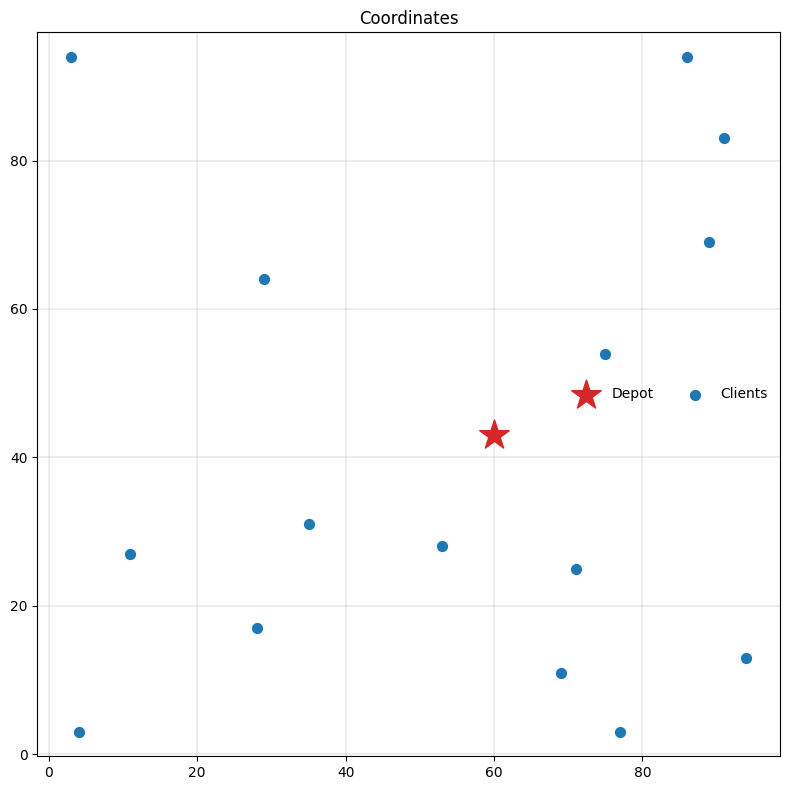

In [3]:
_, ax = plt.subplots(figsize=(8, 8))
plot_coordinates(model.data(), ax=ax)
plt.tight_layout()

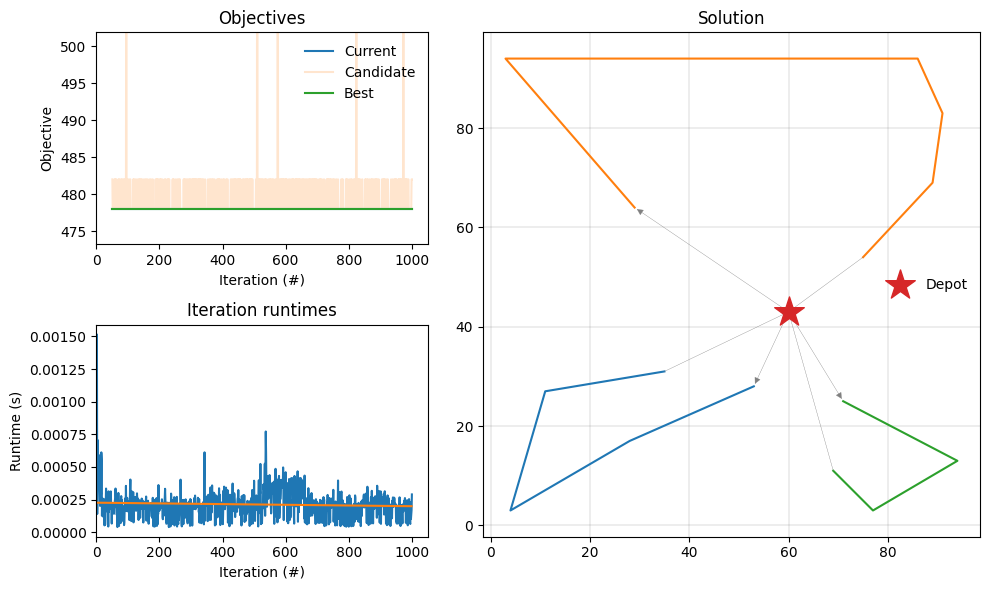

In [4]:
# Visualizar las rutas
fig = plt.figure(figsize=(10, 6))
plot_result(result, model.data(), fig)
fig.tight_layout()